### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | A Naga Sai Karthik     |
| 🆔 **USN**              | 1RUA24CSE0050         |
| **Section**        | G                    |
| **Programme**   | B.Tech(H)             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


**Task 01:** Load the important libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import pathlib
import cv2



#Write your code below this line

In [2]:
from tensorflow.keras import layers

**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
data_dir = /root/.keras/datasets/flower_photos


**Task 03:** Data Exploration

In [4]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos


In [5]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [6]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [7]:
IMG_SIZE = (224, 224)      # Fill
BATCH_SIZE = 32             # Fill
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

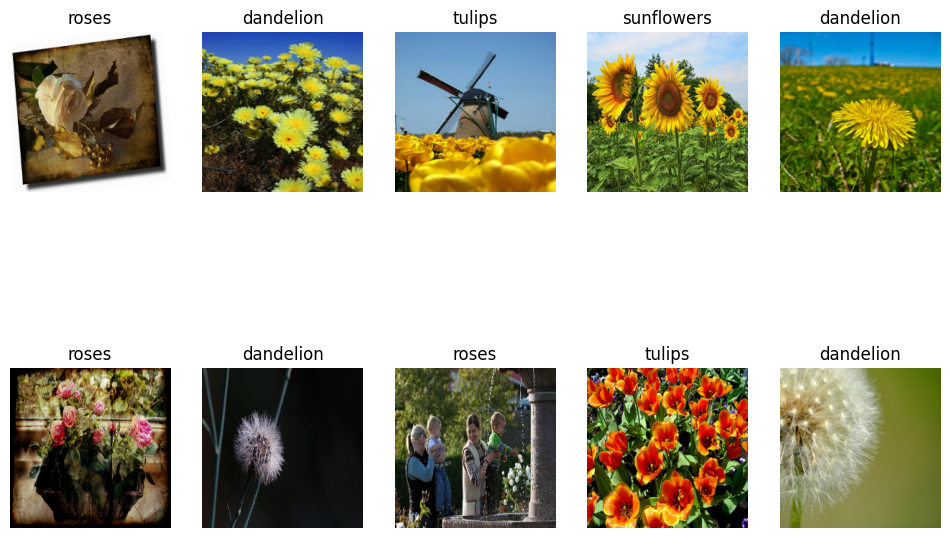

In [8]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

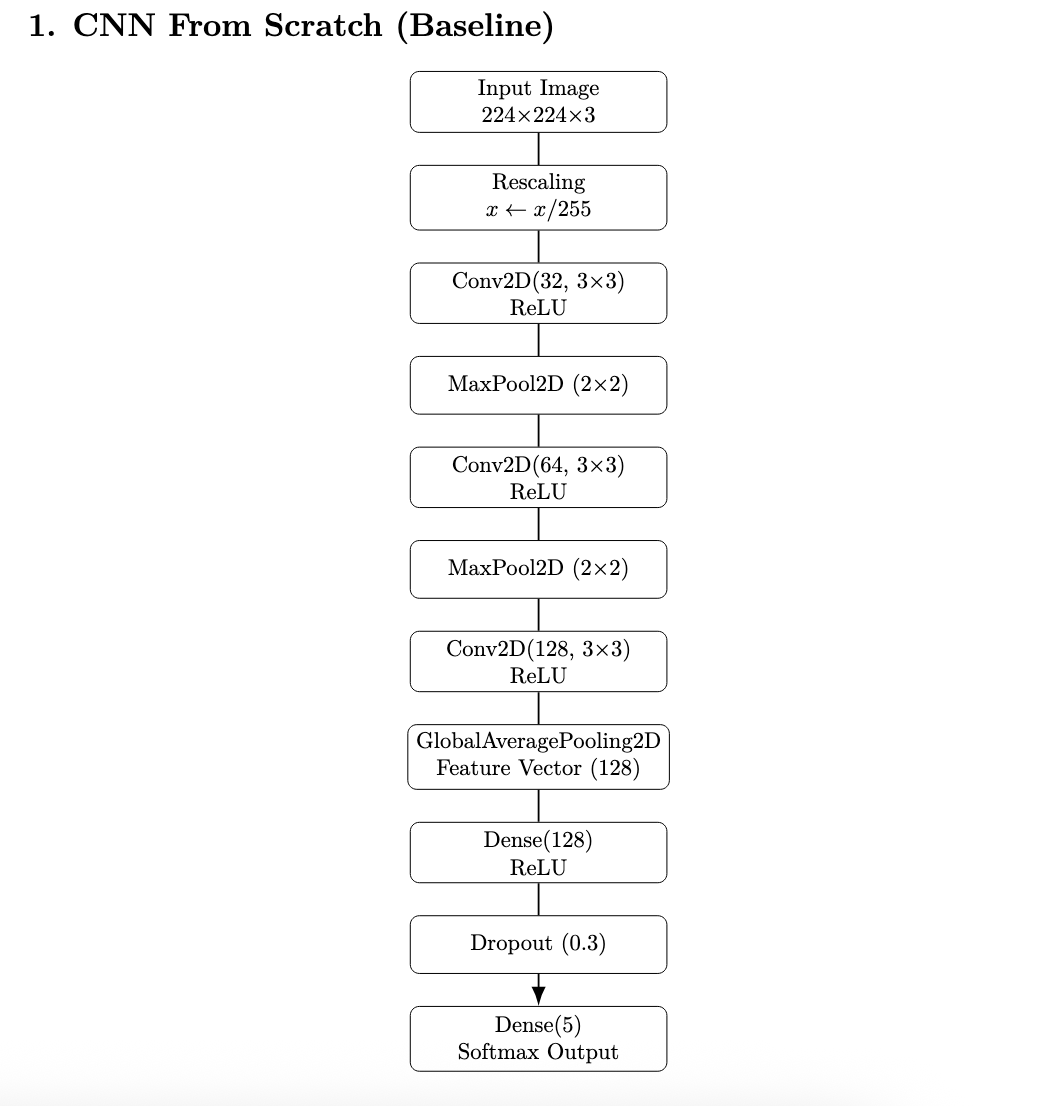

In [10]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),
    normalizer,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [11]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - accuracy: 0.3364 - loss: 1.4451 - val_accuracy: 0.4755 - val_loss: 1.2787
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4686 - loss: 1.2420 - val_accuracy: 0.4547 - val_loss: 1.2274
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4893 - loss: 1.1884 - val_accuracy: 0.5071 - val_loss: 1.1949
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5245 - loss: 1.1393 - val_accuracy: 0.5060 - val_loss: 1.1444
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5383 - loss: 1.1159 - val_accuracy: 0.5453 - val_loss: 1.1042
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5815 - loss: 1.0660 - val_accuracy: 0.5169 - val_loss: 1.1716
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5845 - loss: 1.0459 - val_accuracy: 0.5911 - val_loss: 1.0268
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6004 - loss: 1.0083 - val_accuracy: 0.5802 -

Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

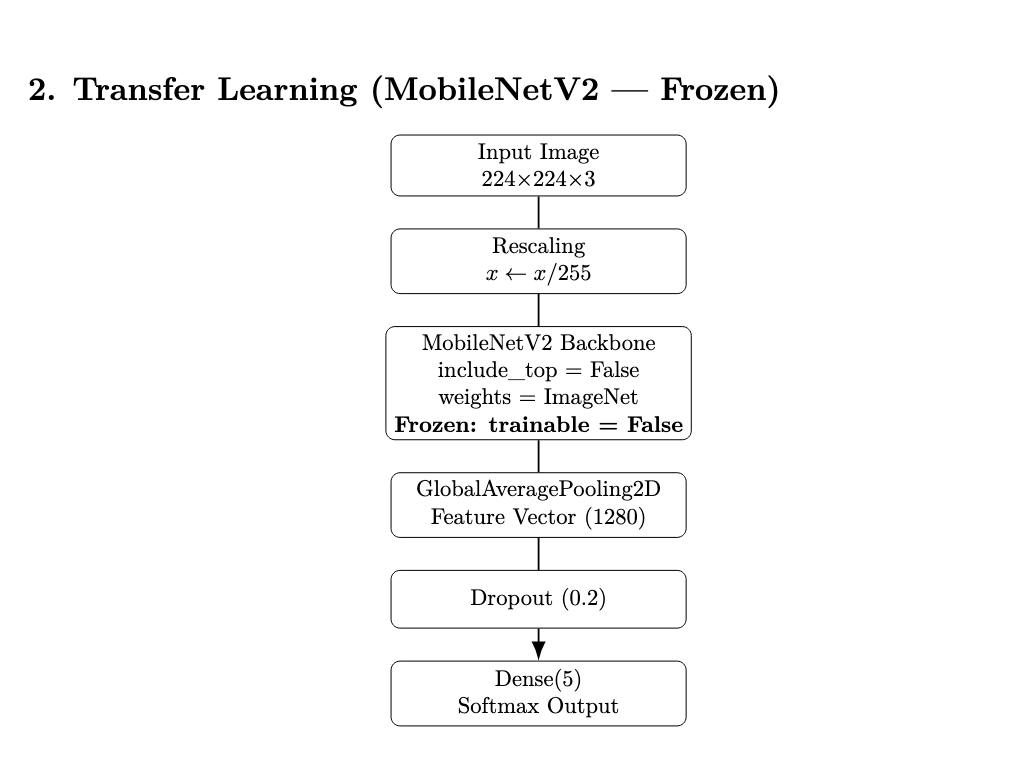

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights = "imagenet"        # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    normalizer,
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [14]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 52s 389ms/step - accuracy: 0.6709 - loss: 0.8744 - val_accuracy: 0.8288 - val_loss: 0.5015
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8275 - loss: 0.4650 - val_accuracy: 0.8670 - val_loss: 0.4041
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8660 - loss: 0.3820 - val_accuracy: 0.8768 - val_loss: 0.3750
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8849 - loss: 0.3257 - val_accuracy: 0.8790 - val_loss: 0.3584
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8983 - loss: 0.3010 - val_accuracy: 0.8724 - val_loss: 0.3417
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9165 - loss: 0.2600 - val_accuracy: 0.8899 - val_loss: 0.3264
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9215 - loss: 0.2429 - val_accuracy: 0.8909 - val_loss: 0.3312
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9277 - loss: 0.2273 - val_accuracy: 0.8855 -

#Compare the Learning curves of both

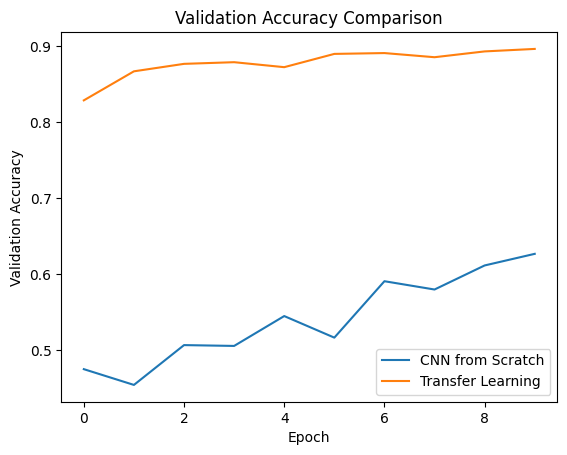

In [15]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [16]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,10,110405,0.627045
1,Transfer Learning,10,2264389,0.896401


## Answer the following questions:

1. Which model converges faster?
2. Which model shows higher validation accuracy?
3. Does CNN from scratch show signs of overfitting? Explain.
4. Why does TL have many parameters but few trainable ones?
5. Why does freezing layers reduce training time?
6. Which model requires more data to train effectively?

## Prediction on Validation Data

In [17]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [18]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.627
Transfer Learning Test Accuracy: 0.8964


<Figure size 640x480 with 0 Axes>

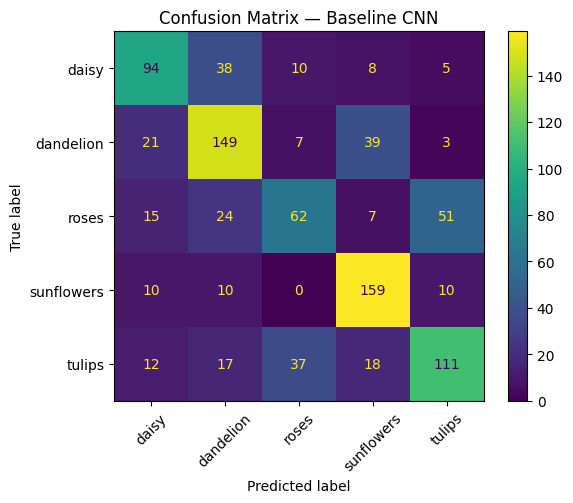

<Figure size 640x480 with 0 Axes>

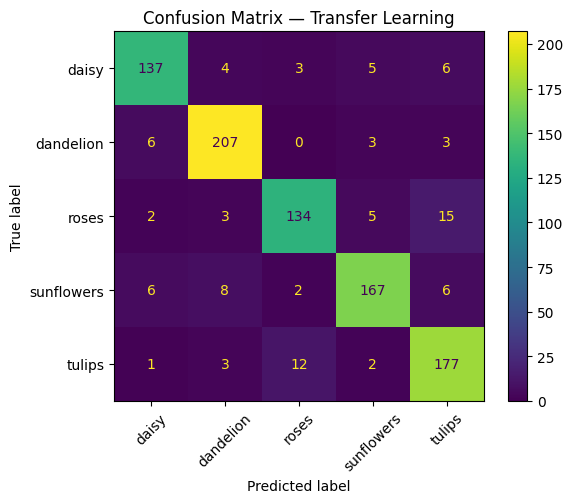

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?
2. Which class shows highest accuracy in TL model?
3. Why might “roses” be harder to classify than “sunflowers”?

In [20]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.62      0.61      0.61       155
   dandelion       0.63      0.68      0.65       219
       roses       0.53      0.39      0.45       159
  sunflowers       0.69      0.84      0.76       189
      tulips       0.62      0.57      0.59       195

    accuracy                           0.63       917
   macro avg       0.62      0.62      0.61       917
weighted avg       0.62      0.63      0.62       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.90      0.88      0.89       155
   dandelion       0.92      0.95      0.93       219
       roses       0.89      0.84      0.86       159
  sunflowers       0.92      0.88      0.90       189
      tulips       0.86      0.91      0.88       195

    accuracy                           0.90       917
   macro avg       0.90      0.89      0.89       917
weighted avg    

## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?
2.	How much did overall accuracy improve using TL?
3.	Why does precision differ from recall?

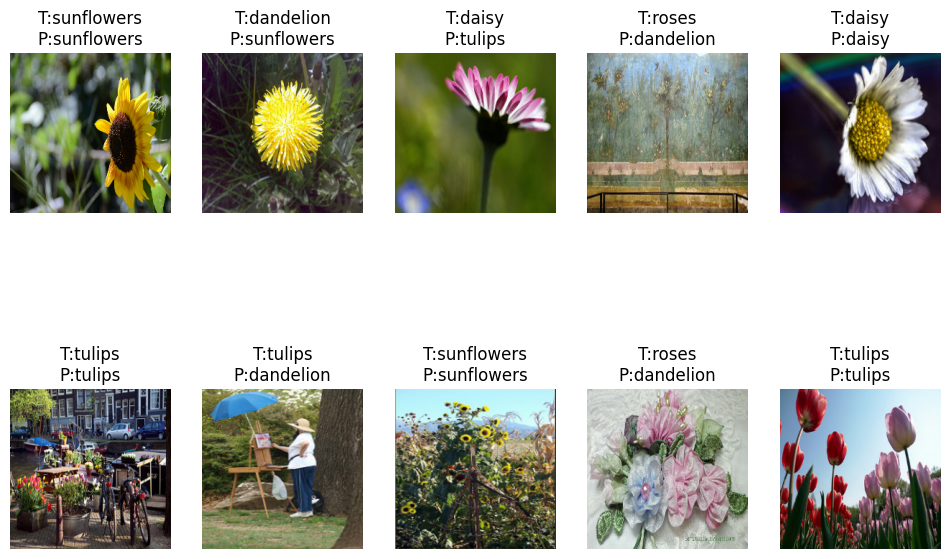

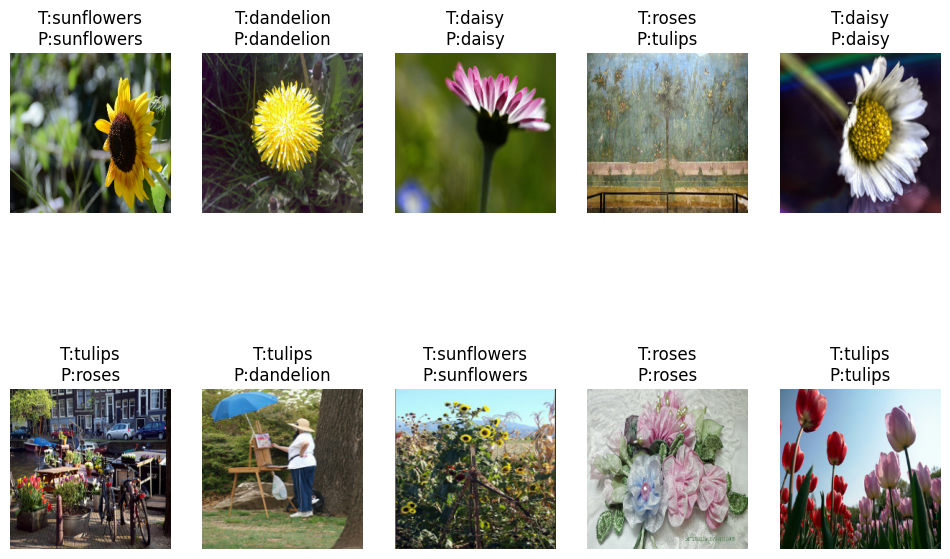

In [21]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:

	1.	Why does TL have many parameters but few trainable ones?
	2.	Why does freezing layers reduce training time?
	3.	Which model requires more data to train effectively?

**Final Task for Students:** Fine-Tuning Task - Unfreeze last layers of MobileNetV2 and retrain for 3 epochs.

Interpret:

	•	Accuracy change
	•	Overfitting risk

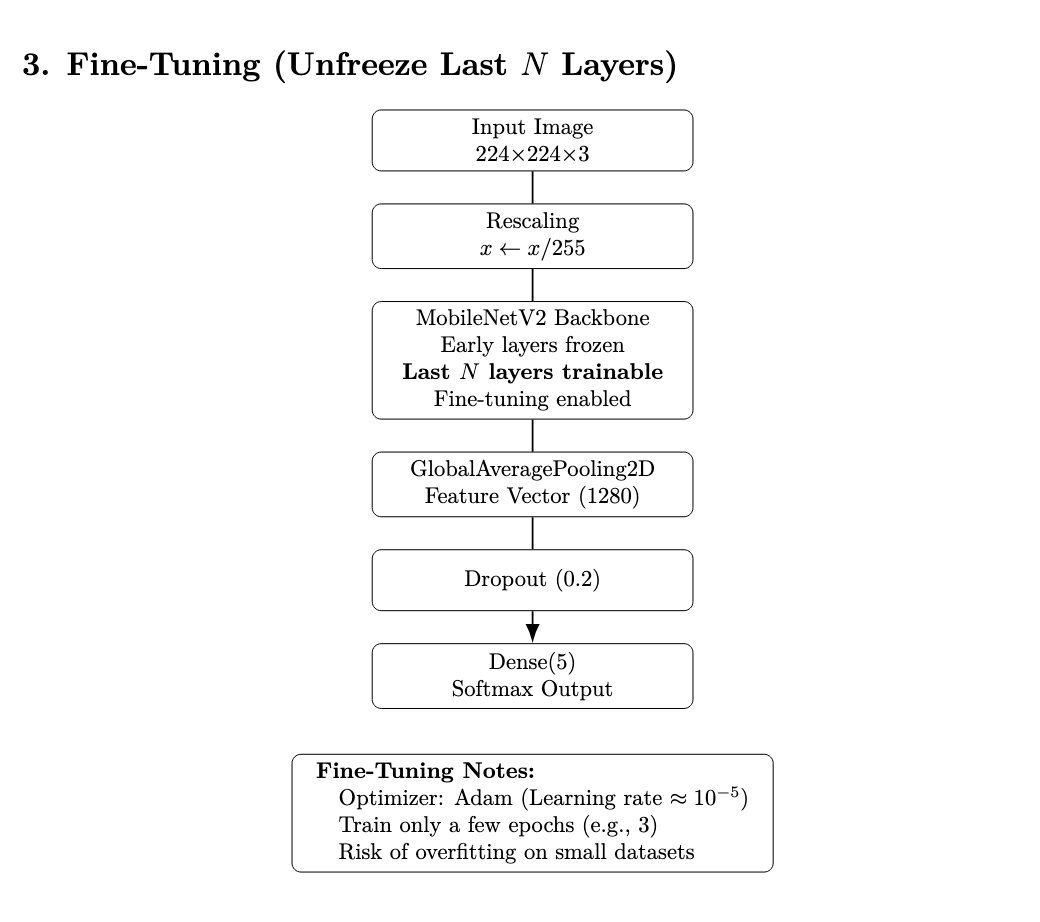

In [22]:
# Write the code here onwards

## Unfreeze the model

In [23]:
base_model.trainable = True

## Freeze most layers and only train the last few layers

In [24]:
fine_tune_at = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total layers in base model:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

# Compile again with a smaller learning rate
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Total layers in base model: 154
Fine-tuning from layer: 115


## Train for 3 epoch

In [25]:
fine_tune_epochs = 3

history_fine = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.8329 - loss: 0.4581 - val_accuracy: 0.8920 - val_loss: 0.3243
Epoch 2/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8976 - loss: 0.2895 - val_accuracy: 0.8866 - val_loss: 0.3274
Epoch 3/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9321 - loss: 0.2173 - val_accuracy: 0.8931 - val_loss: 0.3192


## Evaluate Model

In [26]:
loss, acc = tl_model.evaluate(val_ds)

print("Fine-tuned Model Accuracy:", acc)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8931 - loss: 0.3192
Fine-tuned Model Accuracy: 0.8931297659873962


## Accuracy Change Plot

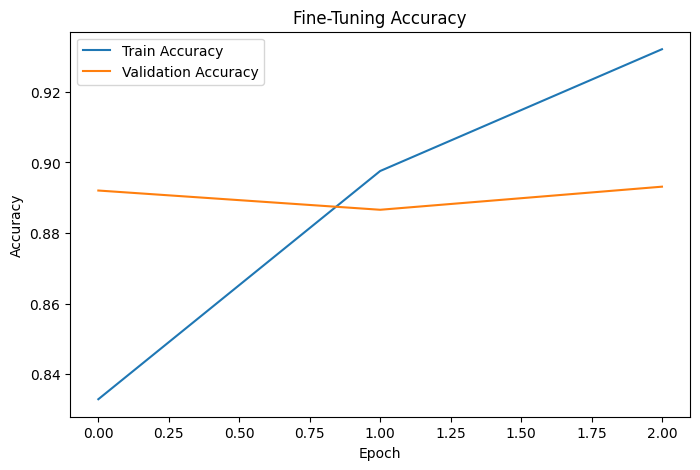

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Predictions after fine-tuning

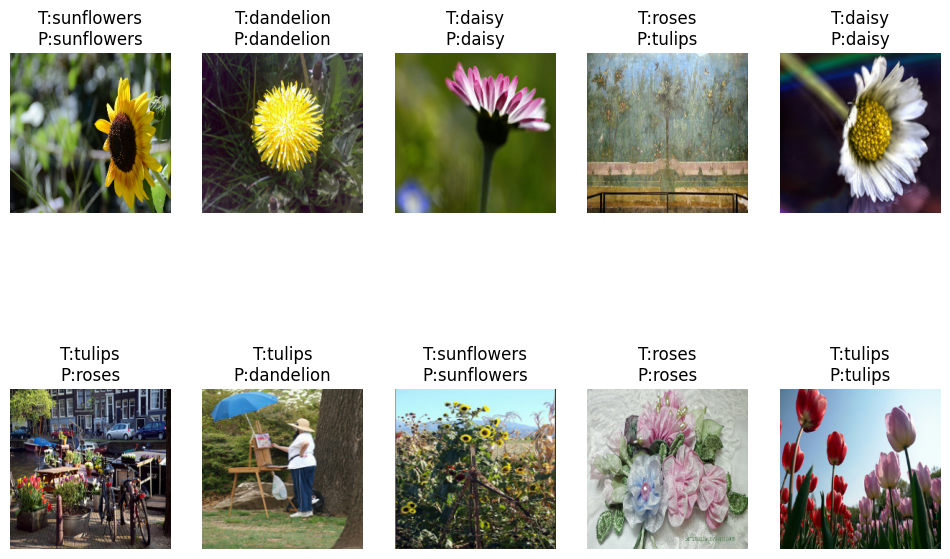

In [28]:
show_prediction_grid(tl_model, val_ds, class_names, n=10)